In [20]:
import os

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import sys
import json
import yaml
import random
import shutil
import logging
import collections
import subprocess
from pathlib import Path

In [ ]:
from pathlib import Path

# 1. COCO/combined 기준 이미지 수 확인
print("coco images 수:", len(coco["images"]))
print("coco annotations 수:", len(coco["annotations"]))

# 2. 전처리 코드에서 나눈 train/val 수 확인
print("train_imgs 수:", len(train_imgs))
print("val_imgs 수:", len(val_imgs))
print("train + val:", len(train_imgs) + len(val_imgs))

# 3. YOLO txt 기준 실제 학습에 들어간 이미지 수 확인
train_txt = Path("/Users/haru/Desktop/medication-detection/data/yolo/train.txt")
val_txt   = Path("/Users/haru/Desktop/medication-detection/data/yolo/val.txt")

print("train.txt 존재?", train_txt.exists())
print("val.txt 존재?", val_txt.exists())

if train_txt.exists() and val_txt.exists():
    train_lines = [l for l in train_txt.read_text(encoding="utf-8").splitlines() if l.strip()]
    val_lines   = [l for l in val_txt.read_text(encoding="utf-8").splitlines() if l.strip()]

    print("train.txt 이미지 수:", len(train_lines))
    print("val.txt 이미지 수:", len(val_lines))
    print("합계:", len(train_lines) + len(val_lines))
    print("batch=8 기준 train iteration:", len(train_lines) // 8)

In [21]:
try:
    import ultralytics
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "ultralytics", "-q"],
        check=True
    )

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# 한글 폰트 설정
mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
log = logging.getLogger("HR")

random.seed(42)
np.random.seed(42)

In [22]:
def find_project_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]

    candidates += [
        Path.home() / "Desktop" / "medication-detection",
        Path.home() / "medication-detection",
    ]

    for candidate in candidates:
        if (candidate / "data" / "raw").is_dir():
            return candidate

    checked = "\n".join(str(c / "data" / "raw") for c in candidates)
    raise FileNotFoundError(f"data/raw 폴더를 찾지 못함. 확인한 경로:\n{checked}")


ROOT = find_project_root()

DATA_RAW  = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"

KAGGLE_ROOT = DATA_RAW / "kaggle_data"
KAGGLE_IMG  = KAGGLE_ROOT / "train_images"
KAGGLE_TEST = KAGGLE_ROOT / "test_images"

AIHUB_ROOT = DATA_RAW / "aihub_data"
AIHUB_IMG  = AIHUB_ROOT / "aihub_images"
AIHUB_ANN  = AIHUB_ROOT / "aihub_annotations"

# 새 YOLO 표준 데이터셋 폴더
YOLO_DIR = ROOT / "data" / "yolo_hr"
YOLO_IMG_TRAIN = YOLO_DIR / "images" / "train"
YOLO_IMG_VAL   = YOLO_DIR / "images" / "val"
YOLO_LAB_TRAIN = YOLO_DIR / "labels" / "train"
YOLO_LAB_VAL   = YOLO_DIR / "labels" / "val"

MODELS_DIR = ROOT / "models"

for d in [
    DATA_PROC,
    YOLO_IMG_TRAIN,
    YOLO_IMG_VAL,
    YOLO_LAB_TRAIN,
    YOLO_LAB_VAL,
    MODELS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

log.info("ROOT        : %s", ROOT)
log.info("DATA_RAW    : %s | exists=%s", DATA_RAW, DATA_RAW.exists())
log.info("AIHUB_IMG   : %s | exists=%s", AIHUB_IMG, AIHUB_IMG.exists())
log.info("AIHUB_ANN   : %s | exists=%s", AIHUB_ANN, AIHUB_ANN.exists())
log.info("KAGGLE_IMG  : %s | exists=%s", KAGGLE_IMG, KAGGLE_IMG.exists())
log.info("KAGGLE_TEST : %s | exists=%s", KAGGLE_TEST, KAGGLE_TEST.exists())

INFO | ROOT        : /Users/haru/Desktop/medication-detection
INFO | DATA_RAW    : /Users/haru/Desktop/medication-detection/data/raw | exists=True
INFO | AIHUB_IMG   : /Users/haru/Desktop/medication-detection/data/raw/aihub_data/aihub_images | exists=True
INFO | AIHUB_ANN   : /Users/haru/Desktop/medication-detection/data/raw/aihub_data/aihub_annotations | exists=True
INFO | KAGGLE_IMG  : /Users/haru/Desktop/medication-detection/data/raw/kaggle_data/train_images | exists=True
INFO | KAGGLE_TEST : /Users/haru/Desktop/medication-detection/data/raw/kaggle_data/test_images | exists=True


In [23]:
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

log.info("PyTorch version : %s", torch.__version__)
log.info("DEVICE          : %s", DEVICE)
log.info("MPS available   : %s", torch.backends.mps.is_available())


INFO | PyTorch version : 2.5.1
INFO | DEVICE          : mps
INFO | MPS available   : True


In [24]:
def count_files(folder: Path, patterns):
    if not folder.exists():
        return 0

    total = 0
    for pattern in patterns:
        total += sum(1 for _ in folder.rglob(pattern))
    return total


aihub_json_count = count_files(AIHUB_ANN, ["*.json"])
aihub_img_count  = count_files(AIHUB_IMG, ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"])
kaggle_img_count = count_files(KAGGLE_IMG, ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"])

log.info("AIHub annotation json 개수 : %d", aihub_json_count)
log.info("AIHub image 개수           : %d", aihub_img_count)
log.info("Kaggle train image 개수    : %d", kaggle_img_count)

combined_path = DATA_PROC / "combined_train.json"

if not combined_path.exists():
    raise FileNotFoundError(
        f"combined_train.json이 없습니다.\n"
        f"먼저 data/processed/combined_train.json을 만들어야 합니다.\n"
        f"확인 경로: {combined_path}"
    )

with open(combined_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

required_keys = ["images", "annotations", "categories"]
for key in required_keys:
    if key not in coco:
        raise KeyError(f"combined_train.json에 '{key}' 키가 없습니다.")

log.info("combined_train.json 로드 완료")
log.info("images      : %d", len(coco["images"]))
log.info("annotations : %d", len(coco["annotations"]))
log.info("categories  : %d", len(coco["categories"]))



INFO | AIHub annotation json 개수 : 51635
INFO | AIHub image 개수           : 16012
INFO | Kaggle train image 개수    : 232
INFO | combined_train.json 로드 완료
INFO | images      : 10947
INFO | annotations : 27255
INFO | categories  : 56


INFO | 클래스 수     : 56
INFO | 클래스 불균형 : 7.8:1
INFO | bbox area mean=85326.3 std=49784.8 min=2385.0 max=273493.0


,category_id,class_name,count
0,16548,가바토파정 100mg,1523
1,16551,동아가바펜틴정 800mg,1500
2,16232,리피토정 20mg,953
3,16262,크레스토정 20mg,948
4,35206,아토젯정 10/40mg,767
5,29667,리바로정 4mg,764
6,36637,로수젯정10/5밀리그램,756
7,20238,플라빅스정 75mg,750
8,3483,기넥신에프정(은행엽엑스)(수출용),669
9,27733,트윈스타정 40/5mg,584


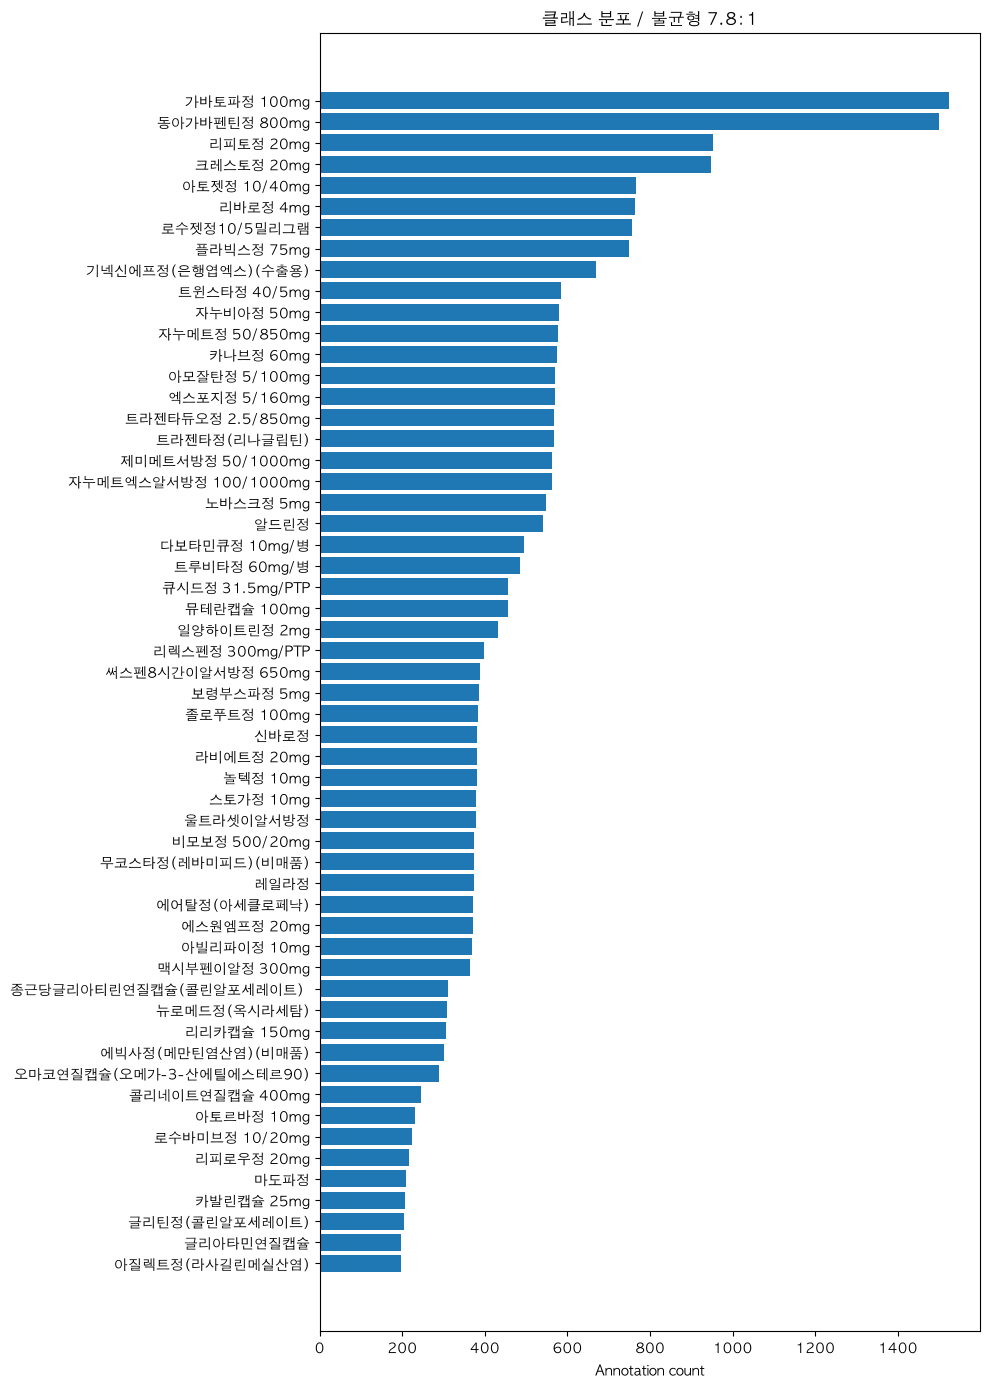

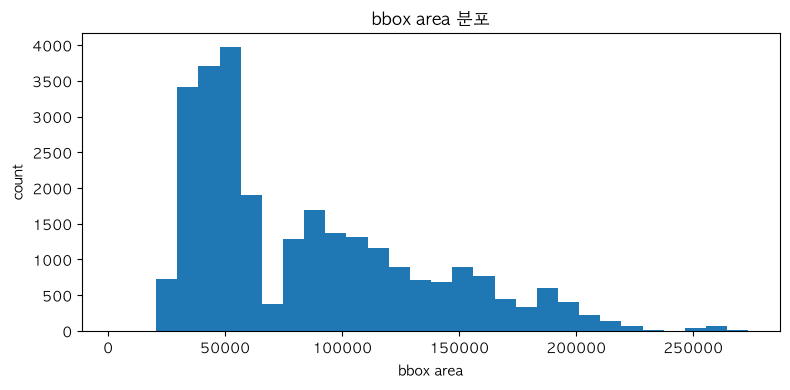

In [25]:
cat_names = {c["id"]: c["name"] for c in coco["categories"]}
cat_ids_sorted = sorted(cat_names.keys())
cat_to_idx = {cid: i for i, cid in enumerate(cat_ids_sorted)}

counter = collections.Counter(a["category_id"] for a in coco["annotations"])

class_df = pd.DataFrame([
    {
        "category_id": cid,
        "class_name": cat_names.get(cid, str(cid)),
        "count": cnt,
    }
    for cid, cnt in counter.items()
]).sort_values("count", ascending=False).reset_index(drop=True)

if len(class_df) > 0:
    ratio = class_df["count"].iloc[0] / max(class_df["count"].iloc[-1], 1)
else:
    ratio = 0

areas = []
for a in coco["annotations"]:
    bbox = a.get("bbox", None)
    if bbox and len(bbox) == 4:
        areas.append(bbox[2] * bbox[3])

log.info("클래스 수     : %d", len(class_df))
log.info("클래스 불균형 : %.1f:1", ratio)

if areas:
    log.info(
        "bbox area mean=%.1f std=%.1f min=%.1f max=%.1f",
        float(np.mean(areas)),
        float(np.std(areas)),
        float(np.min(areas)),
        float(np.max(areas)),
    )

display(class_df.head(20))

if len(class_df) > 0:
    plt.figure(figsize=(10, max(4, len(class_df) * 0.25)))
    plt.barh(class_df["class_name"][::-1], class_df["count"][::-1])
    plt.title(f"클래스 분포 / 불균형 {ratio:.1f}:1")
    plt.xlabel("Annotation count")
    plt.tight_layout()
    plt.show()

if areas:
    plt.figure(figsize=(8, 4))
    plt.hist(areas, bins=30)
    plt.title("bbox area 분포")
    plt.xlabel("bbox area")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

In [26]:
def build_image_index(search_dirs):
    image_exts = {
        ".jpg", ".jpeg", ".png", ".bmp", ".webp",
        ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP",
    }

    index = collections.defaultdict(list)
    total = 0

    for search_dir in search_dirs:
        if not search_dir.exists():
            log.warning("이미지 폴더 없음, 건너뜀: %s", search_dir)
            continue

        log.info("이미지 인덱싱 시작: %s", search_dir)

        for p in search_dir.rglob("*"):
            if p.is_file() and p.suffix in image_exts:
                index[p.name].append(p.resolve())
                total += 1

                if total % 10000 == 0:
                    log.info("이미지 %d개 인덱싱 완료", total)

    log.info("이미지 인덱싱 완료: 총 %d개", total)
    log.info("서로 다른 파일명 수: %d개", len(index))

    return index


image_index = build_image_index([KAGGLE_IMG, AIHUB_IMG])


def find_image_path(file_name):
    if file_name is None:
        return None

    # file_name에 폴더가 섞여 있어도 마지막 파일명만 사용
    simple_name = Path(str(file_name)).name

    paths = image_index.get(simple_name)

    if paths:
        return paths[0]

    return None

INFO | 이미지 인덱싱 시작: /Users/haru/Desktop/medication-detection/data/raw/kaggle_data/train_images
INFO | 이미지 인덱싱 시작: /Users/haru/Desktop/medication-detection/data/raw/aihub_data/aihub_images
INFO | 이미지 10000개 인덱싱 완료
INFO | 이미지 인덱싱 완료: 총 16244개
INFO | 서로 다른 파일명 수: 16012개


In [27]:
anns_by_img = collections.defaultdict(list)
for a in coco["annotations"]:
    anns_by_img[a["image_id"]].append(a)

images = coco["images"].copy()
random.shuffle(images)

split_idx = int(len(images) * 0.8)
train_imgs = images[:split_idx]
val_imgs   = images[split_idx:]

log.info("Train images: %d", len(train_imgs))
log.info("Val images  : %d", len(val_imgs))


INFO | Train images: 8757
INFO | Val images  : 2190


In [28]:
def clear_folder(folder: Path):
    folder.mkdir(parents=True, exist_ok=True)

    for p in folder.iterdir():
        if p.is_symlink() or p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)


# 기존 변환 결과를 새로 만들기
for d in [YOLO_IMG_TRAIN, YOLO_IMG_VAL, YOLO_LAB_TRAIN, YOLO_LAB_VAL]:
    clear_folder(d)


def safe_link_or_copy(src: Path, dst: Path):
    """
    Mac에서는 symlink가 빠르고 용량을 거의 안 먹음.
    symlink 실패 시 copy로 대체.
    """
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists() or dst.is_symlink():
        dst.unlink()

    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)


def clip01(x):
    return max(0.0, min(1.0, float(x)))


def make_unique_stem(image_info):
    """
    파일명 중복 방지.
    같은 파일명이 있어도 image_id를 붙여서 YOLO 폴더에서는 고유하게 만든다.
    """
    original = Path(str(image_info["file_name"])).stem
    image_id = image_info["id"]
    return f"{image_id}_{original}"


def convert_one_split(img_list, image_out_dir: Path, label_out_dir: Path, split_name: str):
    converted = 0
    missing_image = 0
    empty_label = 0
    invalid_bbox = 0

    for i, im in enumerate(img_list, start=1):
        file_name = im.get("file_name")
        src_img = find_image_path(file_name)

        if src_img is None:
            missing_image += 1
            continue

        unique_stem = make_unique_stem(im)
        dst_img = image_out_dir / f"{unique_stem}{src_img.suffix.lower()}"
        dst_label = label_out_dir / f"{unique_stem}.txt"

        safe_link_or_copy(src_img, dst_img)

        w_img = im.get("width")
        h_img = im.get("height")

        if not w_img or not h_img:
            # width/height가 없는 경우는 스킵
            missing_image += 1
            continue

        lines = []

        for a in anns_by_img.get(im["id"], []):
            bbox = a.get("bbox")

            if not bbox or len(bbox) != 4:
                invalid_bbox += 1
                continue

            x, y, w, h = bbox

            if w <= 0 or h <= 0:
                invalid_bbox += 1
                continue

            cx = (x + w / 2) / w_img
            cy = (y + h / 2) / h_img
            nw = w / w_img
            nh = h / h_img

            # 완전히 이미지 밖으로 나간 이상 bbox 방지
            cx = clip01(cx)
            cy = clip01(cy)
            nw = clip01(nw)
            nh = clip01(nh)

            if nw <= 0 or nh <= 0:
                invalid_bbox += 1
                continue

            cls_idx = cat_to_idx[a["category_id"]]
            lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if not lines:
            empty_label += 1

        dst_label.write_text("\n".join(lines), encoding="utf-8")
        converted += 1

        if i % 2000 == 0:
            log.info(
                "%s 변환 중: %d/%d, 변환=%d, 이미지 미발견=%d",
                split_name, i, len(img_list), converted, missing_image
            )

    log.info(
        "%s 변환 완료: 변환=%d, 이미지 미발견=%d, 빈 라벨=%d, invalid bbox=%d",
        split_name, converted, missing_image, empty_label, invalid_bbox
    )

    return {
        "split": split_name,
        "converted": converted,
        "missing_image": missing_image,
        "empty_label": empty_label,
        "invalid_bbox": invalid_bbox,
    }


train_summary = convert_one_split(train_imgs, YOLO_IMG_TRAIN, YOLO_LAB_TRAIN, "train")
val_summary   = convert_one_split(val_imgs,   YOLO_IMG_VAL,   YOLO_LAB_VAL,   "val")

log.info("train summary: %s", train_summary)
log.info("val summary  : %s", val_summary)

INFO | train 변환 중: 4000/8757, 변환=3459, 이미지 미발견=541
INFO | train 변환 중: 6000/8757, 변환=5169, 이미지 미발견=831
INFO | train 변환 중: 8000/8757, 변환=6907, 이미지 미발견=1093
INFO | train 변환 완료: 변환=7557, 이미지 미발견=1200, 빈 라벨=0, invalid bbox=0
INFO | val 변환 중: 2000/2190, 변환=1753, 이미지 미발견=247
INFO | val 변환 완료: 변환=1915, 이미지 미발견=275, 빈 라벨=0, invalid bbox=0
INFO | train summary: {'split': 'train', 'converted': 7557, 'missing_image': 1200, 'empty_label': 0, 'invalid_bbox': 0}
INFO | val summary  : {'split': 'val', 'converted': 1915, 'missing_image': 275, 'empty_label': 0, 'invalid_bbox': 0}


In [29]:
def clear_folder(folder: Path):
    folder.mkdir(parents=True, exist_ok=True)

    for p in folder.iterdir():
        if p.is_symlink() or p.is_file():
            p.unlink()
        elif p.is_dir():
            shutil.rmtree(p)


# 기존 변환 결과를 새로 만들기
for d in [YOLO_IMG_TRAIN, YOLO_IMG_VAL, YOLO_LAB_TRAIN, YOLO_LAB_VAL]:
    clear_folder(d)


def safe_link_or_copy(src: Path, dst: Path):
    """
    Mac에서는 symlink가 빠르고 용량을 거의 안 먹음.
    symlink 실패 시 copy로 대체.
    """
    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists() or dst.is_symlink():
        dst.unlink()

    try:
        os.symlink(src, dst)
    except Exception:
        shutil.copy2(src, dst)


def clip01(x):
    return max(0.0, min(1.0, float(x)))


def make_unique_stem(image_info):
    """
    파일명 중복 방지.
    같은 파일명이 있어도 image_id를 붙여서 YOLO 폴더에서는 고유하게 만든다.
    """
    original = Path(str(image_info["file_name"])).stem
    image_id = image_info["id"]
    return f"{image_id}_{original}"


def convert_one_split(img_list, image_out_dir: Path, label_out_dir: Path, split_name: str):
    converted = 0
    missing_image = 0
    empty_label = 0
    invalid_bbox = 0

    for i, im in enumerate(img_list, start=1):
        file_name = im.get("file_name")
        src_img = find_image_path(file_name)

        if src_img is None:
            missing_image += 1
            continue

        unique_stem = make_unique_stem(im)
        dst_img = image_out_dir / f"{unique_stem}{src_img.suffix.lower()}"
        dst_label = label_out_dir / f"{unique_stem}.txt"

        safe_link_or_copy(src_img, dst_img)

        w_img = im.get("width")
        h_img = im.get("height")

        if not w_img or not h_img:
            # width/height가 없는 경우는 스킵
            missing_image += 1
            continue

        lines = []

        for a in anns_by_img.get(im["id"], []):
            bbox = a.get("bbox")

            if not bbox or len(bbox) != 4:
                invalid_bbox += 1
                continue

            x, y, w, h = bbox

            if w <= 0 or h <= 0:
                invalid_bbox += 1
                continue

            cx = (x + w / 2) / w_img
            cy = (y + h / 2) / h_img
            nw = w / w_img
            nh = h / h_img

            # 완전히 이미지 밖으로 나간 이상 bbox 방지
            cx = clip01(cx)
            cy = clip01(cy)
            nw = clip01(nw)
            nh = clip01(nh)

            if nw <= 0 or nh <= 0:
                invalid_bbox += 1
                continue

            cls_idx = cat_to_idx[a["category_id"]]
            lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if not lines:
            empty_label += 1

        dst_label.write_text("\n".join(lines), encoding="utf-8")
        converted += 1

        if i % 2000 == 0:
            log.info(
                "%s 변환 중: %d/%d, 변환=%d, 이미지 미발견=%d",
                split_name, i, len(img_list), converted, missing_image
            )

    log.info(
        "%s 변환 완료: 변환=%d, 이미지 미발견=%d, 빈 라벨=%d, invalid bbox=%d",
        split_name, converted, missing_image, empty_label, invalid_bbox
    )

    return {
        "split": split_name,
        "converted": converted,
        "missing_image": missing_image,
        "empty_label": empty_label,
        "invalid_bbox": invalid_bbox,
    }


train_summary = convert_one_split(train_imgs, YOLO_IMG_TRAIN, YOLO_LAB_TRAIN, "train")
val_summary   = convert_one_split(val_imgs,   YOLO_IMG_VAL,   YOLO_LAB_VAL,   "val")

log.info("train summary: %s", train_summary)
log.info("val summary  : %s", val_summary)

INFO | train 변환 중: 4000/8757, 변환=3459, 이미지 미발견=541
INFO | train 변환 중: 6000/8757, 변환=5169, 이미지 미발견=831
INFO | train 변환 중: 8000/8757, 변환=6907, 이미지 미발견=1093
INFO | train 변환 완료: 변환=7557, 이미지 미발견=1200, 빈 라벨=0, invalid bbox=0
INFO | val 변환 중: 2000/2190, 변환=1753, 이미지 미발견=247
INFO | val 변환 완료: 변환=1915, 이미지 미발견=275, 빈 라벨=0, invalid bbox=0
INFO | train summary: {'split': 'train', 'converted': 7557, 'missing_image': 1200, 'empty_label': 0, 'invalid_bbox': 0}
INFO | val summary  : {'split': 'val', 'converted': 1915, 'missing_image': 275, 'empty_label': 0, 'invalid_bbox': 0}


In [30]:
data_yaml = {
    "path": str(YOLO_DIR),
    "train": "images/train",
    "val": "images/val",
    "nc": len(cat_ids_sorted),
    "names": [cat_names[cid] for cid in cat_ids_sorted],
}

yaml_path = YOLO_DIR / "data.yaml"

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True, default_flow_style=False, sort_keys=False)

log.info("data.yaml 저장 완료: %s", yaml_path)
print(yaml_path.read_text(encoding="utf-8")[:1000])

INFO | data.yaml 저장 완료: /Users/haru/Desktop/medication-detection/data/yolo_hr/data.yaml


path: /Users/haru/Desktop/medication-detection/data/yolo_hr
train: images/train
val: images/val
nc: 56
names:
- 보령부스파정 5mg
- 뮤테란캡슐 100mg
- 일양하이트린정 2mg
- 기넥신에프정(은행엽엑스)(수출용)
- 무코스타정(레바미피드)(비매품)
- 알드린정
- 뉴로메드정(옥시라세탐)
- 에어탈정(아세클로페낙)
- 리렉스펜정 300mg/PTP
- 아빌리파이정 10mg
- 다보타민큐정 10mg/병
- 써스펜8시간이알서방정 650mg
- 에빅사정(메만틴염산염)(비매품)
- 리피토정 20mg
- 크레스토정 20mg
- 가바토파정 100mg
- 동아가바펜틴정 800mg
- 오마코연질캡슐(오메가-3-산에틸에스테르90)
- 리리카캡슐 150mg
- 종근당글리아티린연질캡슐(콜린알포세레이트) 
- 콜리네이트연질캡슐 400mg
- 트루비타정 60mg/병
- 스토가정 10mg
- 노바스크정 5mg
- 마도파정
- 플라빅스정 75mg
- 엑스포지정 5/160mg
- 아토르바정 10mg
- 라비에트정 20mg
- 리피로우정 20mg
- 자누비아정 50mg
- 맥시부펜이알정 300mg
- 놀텍정 10mg
- 자누메트정 50/850mg
- 큐시드정 31.5mg/PTP
- 아모잘탄정 5/100mg
- 트윈스타정 40/5mg
- 카나브정 60mg
- 울트라셋이알서방정
- 졸로푸트정 100mg
- 트라젠타정(리나글립틴)
- 비모보정 500/20mg
- 레일라정
- 리바로정 4mg
- 트라젠타듀오정 2.5/850mg
- 아질렉트정(라사길린메실산염)
- 자누메트엑스알서방정 100/1000mg
- 글리아타민연질캡슐
- 신바로정
- 에스원엠프정 20mg
- 글리틴정(콜린알포세레이트)
- 제미메트서방정 50/1000mg
- 아토젯정 10/40mg
- 로수젯정10/5밀리그램
- 로수바미브정 10/20mg
- 카발린캡슐 25mg



In [31]:
def count_yolo_files():
    train_img_count = len(list(YOLO_IMG_TRAIN.glob("*")))
    val_img_count   = len(list(YOLO_IMG_VAL.glob("*")))
    train_lab_count = len(list(YOLO_LAB_TRAIN.glob("*.txt")))
    val_lab_count   = len(list(YOLO_LAB_VAL.glob("*.txt")))

    print("===== YOLO 데이터셋 확인 =====")
    print("train images:", train_img_count)
    print("train labels:", train_lab_count)
    print("val images  :", val_img_count)
    print("val labels  :", val_lab_count)

    if train_img_count != train_lab_count:
        print("경고: train 이미지 수와 라벨 수가 다릅니다.")
    if val_img_count != val_lab_count:
        print("경고: val 이미지 수와 라벨 수가 다릅니다.")

    sample_imgs = list(YOLO_IMG_TRAIN.glob("*"))[:3]
    print("\n샘플 이미지/라벨 매칭 확인:")
    for img_path in sample_imgs:
        label_path = YOLO_LAB_TRAIN / f"{img_path.stem}.txt"
        print(img_path.name, "->", label_path.name, "exists=", label_path.exists())


count_yolo_files()

===== YOLO 데이터셋 확인 =====
train images: 7557
train labels: 7557
val images  : 1915
val labels  : 1915

샘플 이미지/라벨 매칭 확인:
8560_K-016206-016232-033880_0_2_0_2_75_000_200.png -> 8560_K-016206-016232-033880_0_2_0_2_75_000_200.txt exists= True
1636_K-001900-016551-029451-044199_0_2_0_2_75_000_200.png -> 1636_K-001900-016551-029451-044199_0_2_0_2_75_000_200.txt exists= True
1515_K-001900-016548-027926-044199_0_2_0_2_70_000_200.png -> 1515_K-001900-016548-027926-044199_0_2_0_2_70_000_200.txt exists= True


In [32]:
if DEVICE == "cuda":
    MODEL_WEIGHTS = "yolov8s.pt"
    EPOCHS = 60
    IMG_SIZE = 640
    BATCH = 8
    TRAIN_DEVICE = "cuda"
    EXP_NAME = "HR_yolov8s_cuda_exp01"

elif DEVICE == "mps":
    MODEL_WEIGHTS = "yolov8n.pt"
    EPOCHS = 3
    IMG_SIZE = 512
    BATCH = 2
    TRAIN_DEVICE = "mps"
    EXP_NAME = "HR_yolov8n_m3_test"

else:
    MODEL_WEIGHTS = "yolov8n.pt"
    EPOCHS = 3
    IMG_SIZE = 512
    BATCH = 2
    TRAIN_DEVICE = "cpu"
    EXP_NAME = "HR_yolov8n_cpu_test"

print("===== 학습 설정 =====")
print("MODEL_WEIGHTS:", MODEL_WEIGHTS)
print("EPOCHS       :", EPOCHS)
print("IMG_SIZE     :", IMG_SIZE)
print("BATCH        :", BATCH)
print("DEVICE       :", TRAIN_DEVICE)
print("EXP_NAME     :", EXP_NAME)

===== 학습 설정 =====
MODEL_WEIGHTS: yolov8n.pt
EPOCHS       : 3
IMG_SIZE     : 512
BATCH        : 2
DEVICE       : mps
EXP_NAME     : HR_yolov8n_m3_test


In [36]:
from pathlib import Path
import random

ROOT = Path("/Users/haru/Desktop/medication-detection")

KAGGLE_IMG = ROOT / "data" / "raw" / "kaggle_data" / "train_images"

img_exts = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# 1. 캐글 원본 이미지 실제 개수 확인
kaggle_images = sorted([
    p for p in KAGGLE_IMG.rglob("*")
    if p.is_file() and p.suffix.lower() in img_exts
])

print("===== 캐글 원본 이미지 확인 =====")
print("KAGGLE_IMG 경로:", KAGGLE_IMG)
print("폴더 존재 여부:", KAGGLE_IMG.exists())
print("캐글 원본 이미지 수:", len(kaggle_images))

# 2. 캐글 원본 기준으로 8:2 split 직접 계산
total = len(kaggle_images)
train_n = int(total * 0.8)
val_n = total - train_n

print("\n===== 캐글 원본 기준 8:2 계산 =====")
print("전체:", total)
print("train:", train_n)
print("val:", val_n)

# 3. 실제 랜덤 split을 했을 때도 확인
random.seed(42)
imgs = kaggle_images.copy()
random.shuffle(imgs)

train_imgs_kaggle = imgs[:train_n]
val_imgs_kaggle = imgs[train_n:]

print("\n===== 실제 split 결과 =====")
print("train_imgs_kaggle:", len(train_imgs_kaggle))
print("val_imgs_kaggle:", len(val_imgs_kaggle))
print("합계:", len(train_imgs_kaggle) + len(val_imgs_kaggle))

# 4. 만약 val이 44장이 되려면 전체가 몇 장인지 역산
print("\n===== val 44장이 되는 경우 =====")
print("44 / 0.2 =", int(44 / 0.2), "장")

===== 캐글 원본 이미지 확인 =====
KAGGLE_IMG 경로: /Users/haru/Desktop/medication-detection/data/raw/kaggle_data/train_images
폴더 존재 여부: True
캐글 원본 이미지 수: 232

===== 캐글 원본 기준 8:2 계산 =====
전체: 232
train: 185
val: 47

===== 실제 split 결과 =====
train_imgs_kaggle: 185
val_imgs_kaggle: 47
합계: 232

===== val 44장이 되는 경우 =====
44 / 0.2 = 220 장


In [33]:
def train_yolo():
    model = YOLO(MODEL_WEIGHTS)

    results = model.train(
        data=str(yaml_path),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=BATCH,
        device=TRAIN_DEVICE,
        workers=0,
        amp=False,
        cache=False,

        project=str(MODELS_DIR),
        name=EXP_NAME,

        optimizer="AdamW",
        lr0=0.001,
        lrf=0.01,
        weight_decay=0.0005,

        hsv_h=0.015,
        hsv_s=0.5,
        hsv_v=0.4,

        mosaic=1.0,
        fliplr=0.5,
        flipud=0.0,
        degrees=10,

        patience=20,
        save=True,
        verbose=True,
    )

    return results


try:
    results = train_yolo()
    log.info("학습 완료")

except RuntimeError as e:
    err_msg = str(e)

    if TRAIN_DEVICE == "mps" and "view size is not compatible" in err_msg:
        log.warning("MPS 호환성 에러 발생. CPU로 자동 재시도합니다.")
        log.warning("에러 내용: %s", err_msg[:500])

        TRAIN_DEVICE = "cpu"
        EXP_NAME = EXP_NAME + "_cpu_retry"

        model = YOLO(MODEL_WEIGHTS)

        results = model.train(
            data=str(yaml_path),
            epochs=EPOCHS,
            imgsz=IMG_SIZE,
            batch=BATCH,
            device=TRAIN_DEVICE,
            workers=0,
            amp=False,
            cache=False,

            project=str(MODELS_DIR),
            name=EXP_NAME,

            optimizer="AdamW",
            lr0=0.001,
            lrf=0.01,
            weight_decay=0.0005,

            hsv_h=0.015,
            hsv_s=0.5,
            hsv_v=0.4,

            mosaic=1.0,
            fliplr=0.5,
            flipud=0.0,
            degrees=10,

            patience=20,
            save=True,
            verbose=True,
        )

        log.info("CPU 재시도 학습 완료")

    else:
        raise

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.5.1 MPS (Apple M3)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/haru/Desktop/medication-detection/data/yolo_hr/data.yaml, degrees=10, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=HR_yolov8n_m3_test, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, o

WARNING | MPS 호환성 에러 발생. CPU로 자동 재시도합니다.
WARNING | 에러 내용: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.


Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.5.1 CPU (Apple M3)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/haru/Desktop/medication-detection/data/yolo_hr/data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=HR_yolov8n_m3_test_cpu_retry, nbs=64, nms=False, opset=None, optimize=False, optimize

KeyboardInterrupt: 